# Exam Hand-In - Data and Things
**Jonas Wolffrom Strandgaard Clausen - jwsc@ruc.dk**

## Imports and Setup

In [52]:
%matplotlib inline

# Standard and math imports
import os
import pandas as pd
import numpy as np

# Plotting libs
import matplotlib.pyplot as plt
import seaborn as sns

# Data Science libs
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Machine Learning libs
from scipy import stats
import statsmodels.api as sm
import shap

# Sklearn imports
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, silhouette_score
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler

---
# 1. Data Transformation and Exploratory Data Analysis (EDA)

**Exercise:** Do an exploratory data analysis of the adult dataset.

**Requirements:**
- Explain what the data is about and which variables the dataset contains
- Explain data types of each variable
- Investigate distribution/variation through visualization and descriptive statistics for each individual variable
- Investigate variation/correlation between pairs of variables:
  - One case where both variables are categorical
  - One case where both variables are numeric
  - One case where one is categorical and one is numeric

## Load and Explore Adult Dataset

In [53]:
adults = pd.read_csv("Data/adult.csv")
adults.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## Dataset Overview and Variable Types

In [54]:
# Dataset information
print("Dataset Shape:", adults.shape)
print("\nColumn Data Types:")
print(adults.dtypes)
print("\nDataset Info:")
adults.info()
print("\nDescriptive Statistics:")
adults.describe()

Dataset Shape: (48842, 15)

Column Data Types:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null 

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## Individual Variable Analysis

### Age Analysis

In [55]:
# Mean age analysis
mean_age = adults["age"].mean()
male_age = adults[adults["sex"] == "Male"]["age"]
mean_male_age = male_age.mean()
female_age = adults[adults["sex"] == "Female"]["age"]
mean_female_age = female_age.mean()

print(f"Overall mean age: {mean_age:.2f}")
print(f"Mean male age: {mean_male_age:.2f}")
print(f"Mean female age: {mean_female_age:.2f}")
print(f"Age difference (Male - Female): {mean_male_age - mean_female_age:.2f}")

Overall mean age: 38.64
Mean male age: 39.49
Mean female age: 36.93
Age difference (Male - Female): 2.57


### Education Analysis

Education Distribution:
       education  people_count
0        HS-grad         15784
1   Some-college         10878
2      Bachelors          8025
3        Masters          2657
4      Assoc-voc          2061
5           11th          1812
6     Assoc-acdm          1601
7           10th          1389
8        7th-8th           955
9    Prof-school           834
10           9th           756
11          12th           657
12     Doctorate           594
13       5th-6th           509
14       1st-4th           247
15     Preschool            83


<Figure size 1200x600 with 0 Axes>

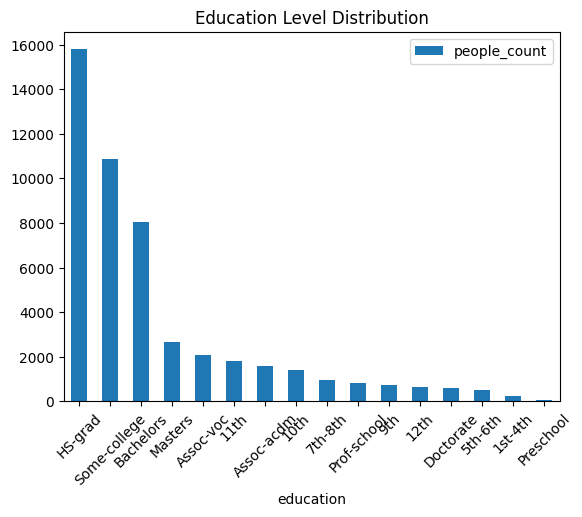

In [56]:
# Education types and counts
educations = adults["education"].value_counts().reset_index()
educations.columns = ["education", "people_count"]
print("Education Distribution:")
print(educations)

# Visualize education distribution
plt.figure(figsize=(12, 6))
educations.plot(x="education", y="people_count", kind="bar", title="Education Level Distribution")
plt.xticks(rotation=45)
plt.show()

## Pairwise Variable Analysis

### Case 1: Both Categorical - Sex vs Education Level

In [57]:
# Education level comparison by sex
male_education_levels = adults[adults["sex"] == "Male"]["education-num"]
mean_male_education_level = male_education_levels.mean()

female_education_levels = adults[adults["sex"] == "Female"]["education-num"]
mean_female_education_level = female_education_levels.mean()

print(f"Mean education level (Male): {mean_male_education_level:.2f}")
print(f"Mean education level (Female): {mean_female_education_level:.2f}")
print(f"Difference: {mean_male_education_level - mean_female_education_level:.2f}")

Mean education level (Male): 10.09
Mean education level (Female): 10.04
Difference: 0.05


### Case 2: Both Numeric - Age vs Hours Worked

Correlation between age and hours per week: 0.0716


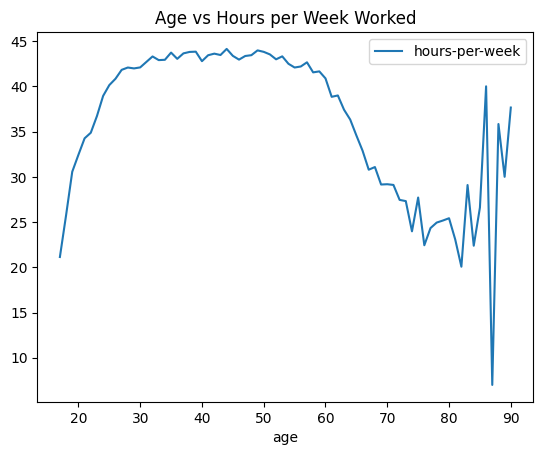

In [58]:
# Correlation between age and hours worked
age_vs_work_hours = pd.DataFrame()
age_vs_work_hours["age"] = adults["age"]
age_vs_work_hours["hours-per-week"] = adults["hours-per-week"]

correlation = age_vs_work_hours["age"].corr(age_vs_work_hours["hours-per-week"])
print(f"Correlation between age and hours per week: {correlation:.4f}")

# Visualize
grouped_age_vs_work_hours = age_vs_work_hours.groupby("age").mean().reset_index()
grouped_age_vs_work_hours.plot(x="age", y="hours-per-week", kind="line", 
                                title="Age vs Hours per Week Worked")
plt.show()

### Case 3: Categorical vs Numeric - Sex vs Income

Income distribution by sex:
income     sex  <=50K  <=50K.  >50K  >50K.
0       Female   9592    4831  1179    590
1         Male  15128    7604  6662   3256


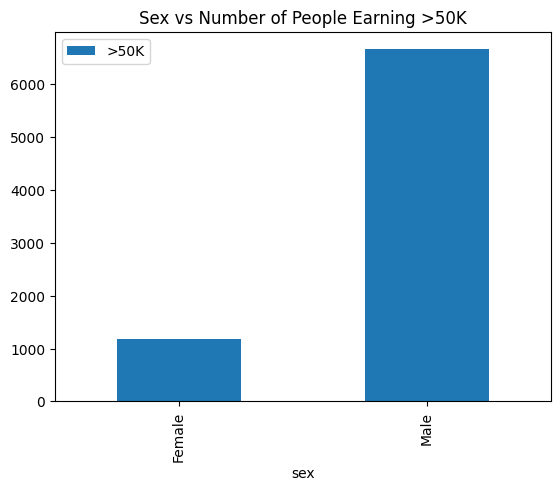

In [59]:
# Income comparison by sex
income_by_sex = pd.DataFrame()
income_by_sex["sex"] = adults["sex"]
income_by_sex["income"] = adults["income"]

grouped_income_by_sex = income_by_sex.groupby("sex").value_counts().unstack().reset_index()
print("Income distribution by sex:")
print(grouped_income_by_sex)

# Visualize
grouped_income_by_sex.plot(x="sex", y=">50K", kind="bar", 
                           title="Sex vs Number of People Earning >50K")
plt.show()

---
# 2. Statistics

**Exercise 3.1:** Using the penguins dataset, answer the following:
1. For different species of penguins, how many penguins are there of each species?
2. Is the body mass variable normally distributed for each species?
3. Test whether there is a difference in body mass for Adelie and Chinstrap penguins
4. Test whether there is a difference in body mass for Chinstrap and Gentoo penguins

**Exercise 3.2:** Load the "fb_like_and_share.csv" data and answer:
1. Is there a difference in distribution of likes for photos and videos?
2. Is there a difference in distribution of share counts for photos and videos?
3. Perform an ANOVA test for shares across post types
4. Is there a statistical significant difference in share counts for any two groups?

## Exercise 3.1: Penguins Analysis

In [60]:
# Load penguins dataset
penguins_data = sns.load_dataset("penguins")
penguins_data.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### 1. Count of penguins per species

     species  count
0     Adelie    152
1     Gentoo    124
2  Chinstrap     68


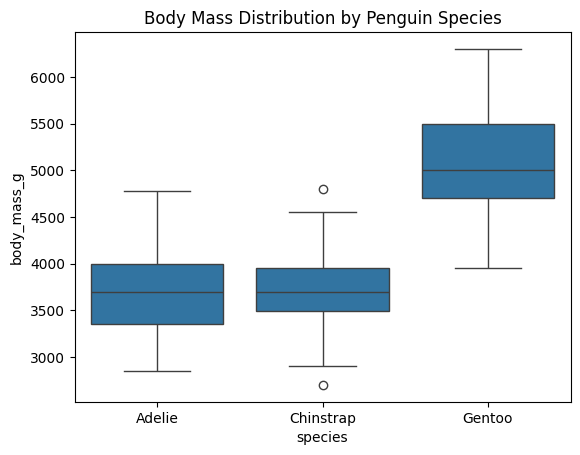

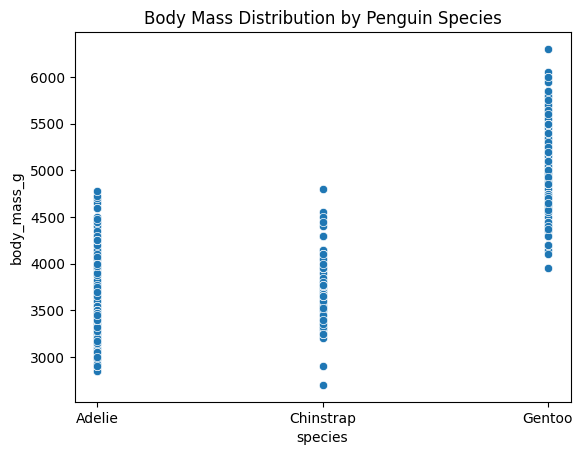

In [61]:
amount_penguins_per_species = penguins_data["species"].value_counts().reset_index()
amount_penguins_per_species.columns = ["species", "count"]
print(amount_penguins_per_species)

# Visualize
sns.boxplot(x="species", y="body_mass_g", data=penguins_data)
plt.title("Body Mass Distribution by Penguin Species")
plt.show()

sns.scatterplot(x="species", y="body_mass_g", data=penguins_data)
plt.title("Body Mass Distribution by Penguin Species")
plt.show()

### 2. Test for normal distribution

In [62]:
adelie_penguins = penguins_data[penguins_data["species"] == "Adelie"]
chinstrap_penguins = penguins_data[penguins_data["species"] == "Chinstrap"]
gentoo_penguins = penguins_data[penguins_data["species"] == "Gentoo"]

# Shapiro-Wilk test for Adelie
statistic, p_value = stats.shapiro(adelie_penguins["body_mass_g"].dropna())
print("Shapiro-Wilk Test for Adelie Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)

# Shapiro-Wilk test for Chinstrap
statistic, p_value = stats.shapiro(chinstrap_penguins["body_mass_g"].dropna())
print("\nShapiro-Wilk Test for Chinstrap Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)

# Shapiro-Wilk test for Gentoo
statistic, p_value = stats.shapiro(gentoo_penguins["body_mass_g"].dropna())
print("\nShapiro-Wilk Test for Gentoo Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", p_value)

Shapiro-Wilk Test for Adelie Penguins Body Mass:
T-statistic: 0.9807078507062791
P-value: 0.03239702501305105

Shapiro-Wilk Test for Chinstrap Penguins Body Mass:
T-statistic: 0.984493761674102
P-value: 0.5605082387697975

Shapiro-Wilk Test for Gentoo Penguins Body Mass:
T-statistic: 0.9859276066609362
P-value: 0.23361648888961845


### 3. Test difference between Adelie and Chinstrap

We see that Chinstrap penguins are likely normally distributed, but Adelie are not. Thus we use a Mann-Whitney U test.

**H₀:** There is no difference in body mass between Adelie and Chinstrap penguins (μ_Adelie = μ_Chinstrap)

**H₁:** There is a difference in body mass between Adelie and Chinstrap penguins (μ_Adelie ≠ μ_Chinstrap)

**α = 0.05**

In [63]:
u_statistic, p_value_u = stats.mannwhitneyu(adelie_penguins["body_mass_g"].dropna(), 
                                            chinstrap_penguins["body_mass_g"].dropna())
print("Mann-Whitney U Test between Adelie and Chinstrap Penguins Body Mass:")
print("U-statistic:", u_statistic)
print("P-value:", p_value_u)
print("\nConclusion: From the result we see that there is no difference in body mass between the two penguin species.")

Mann-Whitney U Test between Adelie and Chinstrap Penguins Body Mass:
U-statistic: 4831.0
P-value: 0.4854772721011861

Conclusion: From the result we see that there is no difference in body mass between the two penguin species.


### 4. Test difference between Chinstrap and Gentoo

With a p-value well above 0.05, Gentoo penguins are likely normally distributed, so we use a t-test.

**H₀:** There is no difference in body mass between Gentoo and Chinstrap penguins (μ_Gentoo = μ_Chinstrap)

**H₁:** There is a difference in body mass between Gentoo and Chinstrap penguins (μ_Gentoo ≠ μ_Chinstrap)

**α = 0.05**

In [64]:
statistic, p_value = stats.ttest_ind(gentoo_penguins["body_mass_g"].dropna(), 
                                     chinstrap_penguins["body_mass_g"].dropna())
print("T-Test between Gentoo and Chinstrap Penguins Body Mass:")
print("T-statistic:", statistic)
print("P-value:", round(p_value, 50))
print("\nConclusion: Seeing as the p-value is very well below 0.05, it strongly suggests that there is a difference in body mass between Gentoo and Chinstrap penguins, thus rejecting the null hypothesis.")

T-Test between Gentoo and Chinstrap Penguins Body Mass:
T-statistic: 19.103227243520955
P-value: 5.2661999999999995e-46

Conclusion: Seeing as the p-value is very well below 0.05, it strongly suggests that there is a difference in body mass between Gentoo and Chinstrap penguins, thus rejecting the null hypothesis.


## Exercise 3.2: Facebook Likes and Shares Analysis

In [65]:
fb_like_and_share = pd.read_csv("Data/fb_like_and_share.csv", sep=";")
fb_like_and_share.head()

,type,likes_count_fb,shares_count_fb
0,video,577,7
1,photo,2802,23
2,video,490,14
3,link,535,16
4,photo,1049,44


In [66]:
fb_photos = fb_like_and_share[fb_like_and_share["type"] == "photo"]
fb_videos = fb_like_and_share[fb_like_and_share["type"] == "video"]

print("Facebook Photos Data:")
print(fb_photos)
print("\nFacebook Videos Data:")
print(fb_videos)

Facebook Photos Data:
     type  likes_count_fb  shares_count_fb
1   photo            2802               23
4   photo            1049               44
5   photo            1557               85
6   photo             838                1
8   photo             100                1
10  photo            1258               19
11  photo             487                5
12  photo             184               12
14  photo             653               43
19  photo             637                3
26  photo            1544               47
27  photo             320                0
28  photo             329                3

Facebook Videos Data:
     type  likes_count_fb  shares_count_fb
0   video             577                7
2   video             490               14
9   video             112                3
13  video            1051               78
17  video              35                0
20  video             116                1
22  video             175                0
30  video

### 1. Test for difference in likes distribution

We begin by assuming both sets are normally distributed, with an α = 0.05

In [67]:
# Test for normality
statistic, p_value = stats.shapiro(fb_photos["likes_count_fb"].dropna())
print("Shapiro-Wilk Test for Facebook Photos Like Count:")
print("T-statistic:", statistic)
print("P-value:", p_value)

statistic, p_value = stats.shapiro(fb_videos["likes_count_fb"].dropna())
print("\nShapiro-Wilk Test for Facebook Videos Like Count:")
print("T-statistic:", statistic)
print("P-value:", p_value)

Shapiro-Wilk Test for Facebook Photos Like Count:
T-statistic: 0.8774655646725982
P-value: 0.06589939260226885

Shapiro-Wilk Test for Facebook Videos Like Count:
T-statistic: 0.8477493538641958
P-value: 0.07038250110283344


Seeing values above 0.05 for both data sets, we can see that the data is normally distributed. We can use a t-test:

**H₀:** There is no difference between like counts (μ_Photos = μ_Videos)

**H₁:** There is a difference between like counts (μ_Photos ≠ μ_Videos)

**α = 0.05**

In [68]:
statistics, p_value = stats.ttest_ind(fb_photos["likes_count_fb"].dropna(), 
                                      fb_videos["likes_count_fb"].dropna())

print("T-Test between Facebook Photos and Videos Like Count:")
print("T-statistic:", statistics)
print("P-value:", p_value)
print("\nConclusion: Looking at the p-value of 0.046, which is below the significance level, we reject the null hypothesis as there's a somewhat strong indication of a difference in like counts between the two sets.")

T-Test between Facebook Photos and Videos Like Count:
T-statistic: 2.125454058083514
P-value: 0.04619850270741723

Conclusion: Looking at the p-value of 0.046, which is below the significance level, we reject the null hypothesis as there's a somewhat strong indication of a difference in like counts between the two sets.


---
# 3. Data Engineering

**Exercise:** Task 7 from DE_Task.ipynb - Wrap functionality into an ETL pipeline.

*Note: This exercise requires the DE_Task.ipynb file which is not included in exercises.ipynb. This section should be completed separately.*

---
# 4. Regression

**Exercise 1 & 2:** Energy Efficiency Dataset Analysis

Tasks:
1. Visualize relationship between SurfaceArea and HeatingLoad
2. Analyze correlation and statistical significance
3. Add OverallHeight as hue in scatterplot
4. Train simple linear regression model
5. Interpret model coefficients
6. Add regression line to scatterplot
7. Evaluate model performance
8. Compare model on subset (OverallHeight=7) vs full dataset

In [69]:
data = pd.read_csv("Data/EnergyEfficiency.csv")
data.head()

,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,HeatingLoad,CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## 1. Visualize SurfaceArea vs HeatingLoad

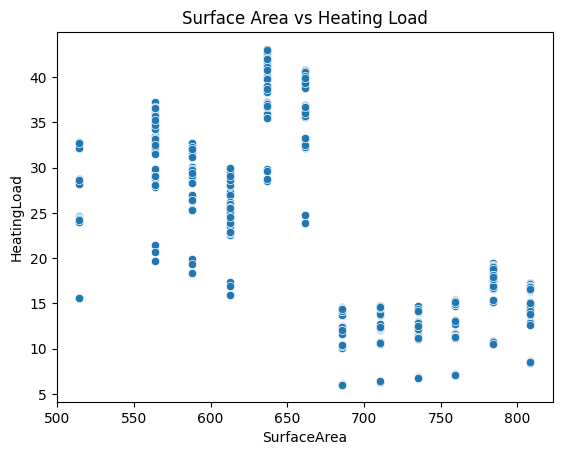

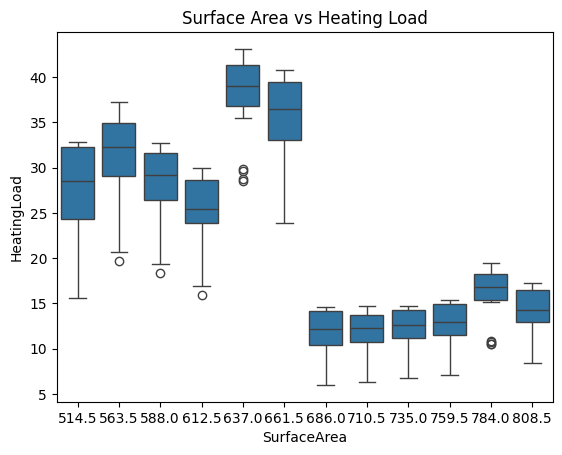

In [70]:
SurfaceArea = data["SurfaceArea"]
HeatingLoad = data["HeatingLoad"]

sns.scatterplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load")
plt.show()

sns.boxplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load")
plt.show()

## 2. Correlation Analysis

In [71]:
correlation = SurfaceArea.corr(HeatingLoad, method='spearman')
print("Correlation between Surface Area and Heating Load:", correlation)

Correlation between Surface Area and Heating Load: -0.6221346966316251


## 3. Scatterplot with OverallHeight Hue

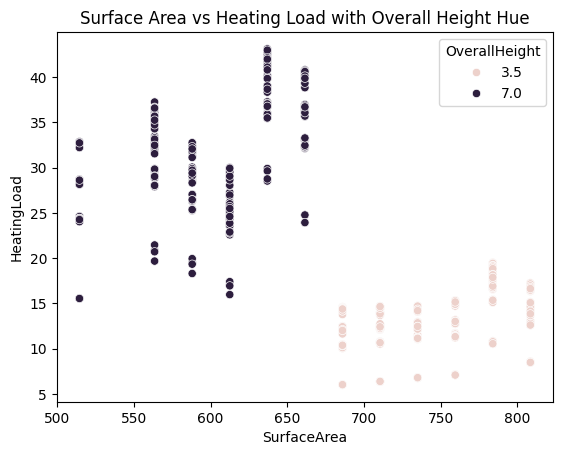

In [72]:
sns.scatterplot(x="SurfaceArea", y="HeatingLoad", hue="OverallHeight", data=data)
plt.title("Surface Area vs Heating Load with Overall Height Hue")
plt.show()

## 4. Train Linear Regression Model

In [73]:
# Add constant term (intercept)
X = sm.add_constant(SurfaceArea)

# Verify the relationship
print("Correlation:", SurfaceArea.corr(HeatingLoad))
print("\nFirst few values:")
print("SurfaceArea:", SurfaceArea.head().values)
print("HeatingLoad:", HeatingLoad.head().values)

linreg_statsm = sm.OLS(HeatingLoad, X).fit()

Correlation: -0.658120226777621

First few values:
SurfaceArea: [514.5 514.5 514.5 514.5 563.5]
HeatingLoad: [15.55 15.55 15.55 15.55 20.84]


## 5. Model Summary and Coefficients

In [74]:
print(linreg_statsm.summary())

b = linreg_statsm.params
print("\nModel Coefficients:")
print(b)

                            OLS Regression Results                            
Dep. Variable:            HeatingLoad   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     585.3
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.69e-96
Time:                        14:32:33   Log-Likelihood:                -2646.6
No. Observations:                 768   AIC:                             5297.
Df Residuals:                     766   BIC:                             5306.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          72.9454      2.111     34.554      

## 6. Regression Line Visualization

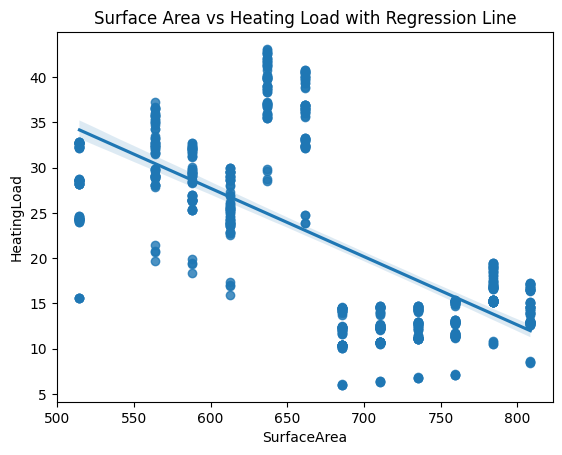

In [75]:
sns.regplot(x="SurfaceArea", y="HeatingLoad", data=data)
plt.title("Surface Area vs Heating Load with Regression Line")
plt.show()

## 7. Model Evaluation

In [76]:
print("R-squared:", linreg_statsm.rsquared)
print("Adjusted R-squared:", linreg_statsm.rsquared_adj)
print("\nMean Absolute Error (MAE):", np.mean(np.abs(linreg_statsm.resid)))
print("Mean Squared Error (MSE):", np.mean(linreg_statsm.resid**2))

R-squared: 0.433122232893828
Adjusted R-squared: 0.43238218358951186

Mean Absolute Error (MAE): 6.002338517195692
Mean Squared Error (MSE): 57.63983779426345


---
# 5. Time Series

**Exercise:** Tasks 3, 4, and 6 from TSA_Task
- Clean dataset
- Create at least 5 new features with justification
- Train XGBoost model
- Explain train/test/validation split
- Calculate RMSE and MAE evaluation metrics

In [77]:
# Download bike sharing dataset
path = kagglehub.dataset_download("lakshmi25npathi/bike-sharing-dataset")
print("Path to dataset files:", path)

files = os.listdir(path)
print("Files in dataset:", files)

hour = pd.read_csv(os.path.join(path, "hour.csv"))
print("\nFirst 5 records:")
hour.head()

Path to dataset files: /home/xilas/.cache/kagglehub/datasets/lakshmi25npathi/bike-sharing-dataset/versions/1
Files in dataset: ['Readme.txt', 'hour.csv', 'day.csv']

First 5 records:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## Data Cleaning and Exploration

In [78]:
# Check for missing values
print("Missing values:")
print(hour.isnull().sum())

# Dataset info
print("\nDataset info:")
hour.info()

# Convert date column
hour["dteday"] = pd.to_datetime(hour["dteday"])

# Check duplicates
print("\nDuplicates:", hour.duplicated().sum())

# Descriptive statistics
print("\nDescriptive statistics:")
print(hour.describe())

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum    

## Feature Engineering

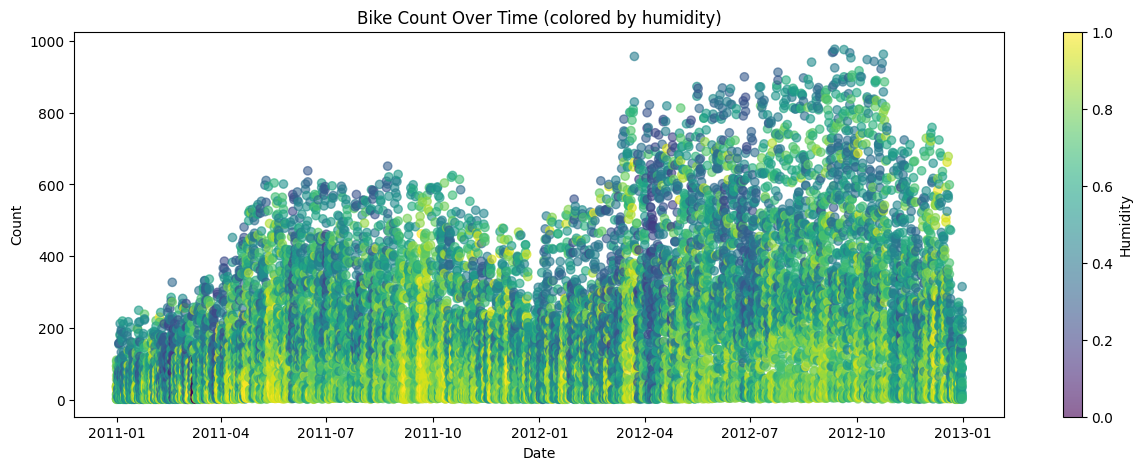

In [79]:
# Create datetime features
hour["datetime_obj"] = pd.to_datetime(hour["dteday"])
hour["Day"] = hour["datetime_obj"].dt.hour
hour["Week"] = hour["datetime_obj"].dt.dayofweek
hour["Month"] = hour["datetime_obj"].dt.month
hour["Year"] = hour["datetime_obj"].dt.year

# Visualize bike counts over time
plt.figure(figsize=(15, 5))
plt.scatter(hour["dteday"], hour["cnt"], c=hour["hum"], cmap="viridis", alpha=0.6)
plt.colorbar(label="Humidity")
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Bike Count Over Time (colored by humidity)")
plt.show()

## Rolling Mean Features

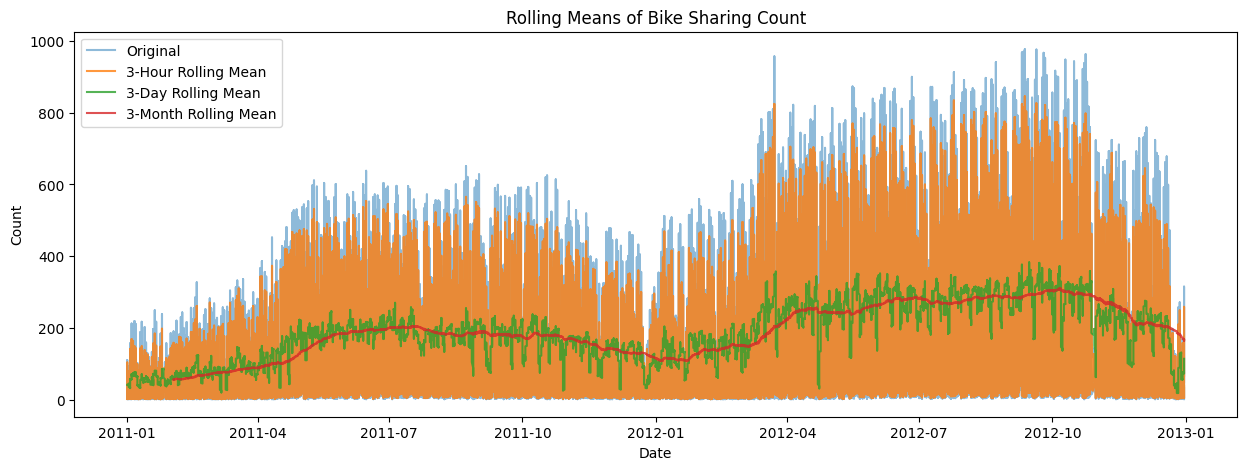

In [80]:
# Create rolling mean features
last_3_hour_rolling_mean = hour["cnt"].rolling(window=3).mean()
last_3_day_rolling_mean = hour["cnt"].rolling(window=24).mean()
last_3_month_rolling_mean = hour["cnt"].rolling(window=24*30).mean()

# Visualize rolling means
plt.figure(figsize=(15, 5))
plt.plot(hour["dteday"], hour["cnt"], label="Original", alpha=0.5)
plt.plot(hour["dteday"], last_3_hour_rolling_mean, label="3-Hour Rolling Mean", alpha=0.8)
plt.plot(hour["dteday"], last_3_day_rolling_mean, label="3-Day Rolling Mean", alpha=0.8)
plt.plot(hour["dteday"], last_3_month_rolling_mean, label="3-Month Rolling Mean", alpha=0.8)
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Rolling Means of Bike Sharing Count")
plt.legend()
plt.show()

---
# 6. Classification

**Exercise 2:** KNN Classifier on Titanic Dataset

Tasks:
1. Load titanic dataset, select features and target
2. Handle missing values
3. Create dummy variables
4. Train-test split (20%, random_state=962)
5. Scale data
6. Train KNN models for multiple K values (2-50)
7. Plot train/test precision and recall
8. Select best K for precision and recall
9. Create confusion matrices and calculate metrics

In [81]:
# Load titanic dataset
titanic_data = pd.read_csv("Data/titanic_survival_data.csv")
titanic_data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.250,S
1,1,1,female,38.0,1,0,712.833,C
2,1,3,female,26.0,0,0,7.925,S
3,1,1,female,35.0,1,0,53.100,S
4,0,3,male,35.0,0,0,8.050,S


## Data Preparation

In [82]:
# Select features and target
X = titanic_data[["Pclass", "Sex", "Age", "Fare"]]
Y = titanic_data["Survived"]

# Fill missing values with mean
X["Age"] = X["Age"].fillna(X["Age"].mean())
X["Fare"] = X["Fare"].fillna(X["Fare"].mean())

# Get dummies for categorical columns
X = pd.get_dummies(X, columns=["Sex", "Pclass"])
X.head()

,Age,Fare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
0,22.0,7.250,False,True,False,False,True
1,38.0,712.833,True,False,True,False,False
2,26.0,7.925,True,False,False,False,True
3,35.0,53.100,True,False,True,False,False
4,35.0,8.050,False,True,False,False,True


## Train-Test Split and Scaling

In [83]:
# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=962)

# Scale the data
scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head()

,Age,Fare,Sex_female,Sex_male,Pclass_1,Pclass_2,Pclass_3
109,-0.001709,-0.417652,1.389259,-1.389259,-0.575188,-0.520988,0.926827
622,-0.749967,0.432741,-0.719808,0.719808,-0.575188,-0.520988,0.926827
789,1.259968,-0.066371,-0.719808,0.719808,1.738562,-0.520988,-1.078950
562,-0.131525,-0.485611,-0.719808,0.719808,-0.575188,1.919430,-1.078950
75,-0.363441,-0.522940,-0.719808,0.719808,-0.575188,-0.520988,0.926827


## Train KNN Models for Multiple K Values

In [84]:
# Train KNN models for k from 2 to 50
k_values = range(2, 51)
train_accuracies = []
test_accuracies = []
train_precisions = []
test_precisions = []
train_recalls = []
test_recalls = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, Y_train)
    
    Y_train_pred = knn.predict(X_train_scaled)
    Y_test_pred = knn.predict(X_test_scaled)
    
    train_accuracies.append(accuracy_score(Y_train, Y_train_pred))
    test_accuracies.append(accuracy_score(Y_test, Y_test_pred))
    
    train_precisions.append(precision_score(Y_train, Y_train_pred))
    test_precisions.append(precision_score(Y_test, Y_test_pred))
    
    train_recalls.append(recall_score(Y_train, Y_train_pred))
    test_recalls.append(recall_score(Y_test, Y_test_pred))

print("Training complete for k = 2 to 50")

Training complete for k = 2 to 50


## Visualize Precision and Recall

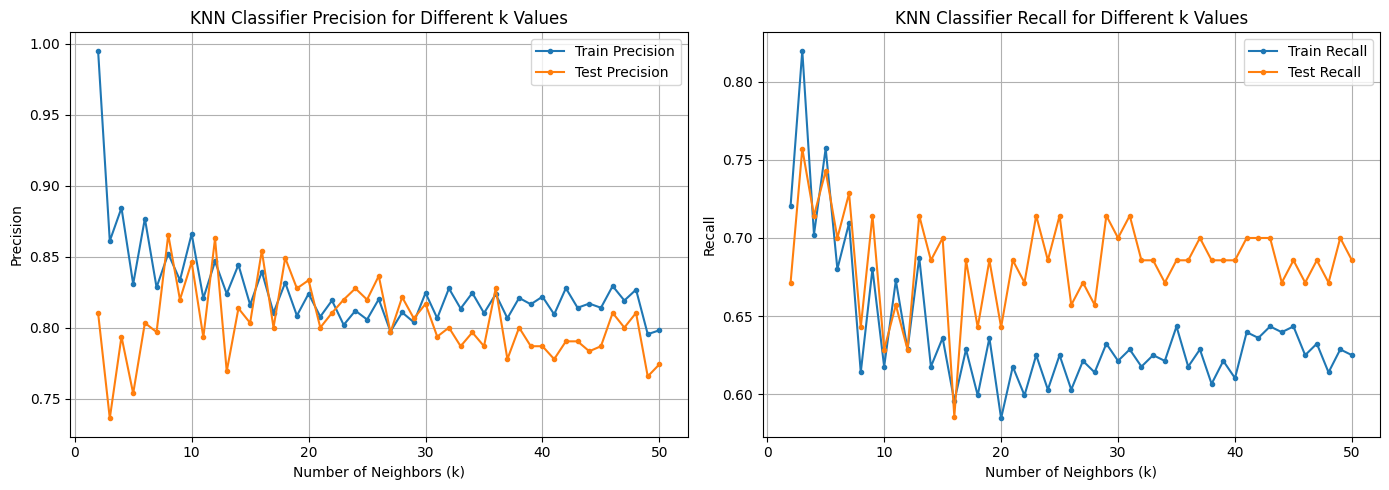

In [85]:
# Plot train and test precision and recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision plot
axes[0].plot(k_values, train_precisions, marker='o', label='Train Precision', markersize=3)
axes[0].plot(k_values, test_precisions, marker='o', label='Test Precision', markersize=3)
axes[0].set_xlabel('Number of Neighbors (k)')
axes[0].set_ylabel('Precision')
axes[0].set_title('KNN Classifier Precision for Different k Values')
axes[0].legend()
axes[0].grid()

# Recall plot
axes[1].plot(k_values, train_recalls, marker='o', label='Train Recall', markersize=3)
axes[1].plot(k_values, test_recalls, marker='o', label='Test Recall', markersize=3)
axes[1].set_xlabel('Number of Neighbors (k)')
axes[1].set_ylabel('Recall')
axes[1].set_title('KNN Classifier Recall for Different k Values')
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

## Find Best K Values

In [86]:
# Find best k for precision and recall (k > 5)
best_precision_k = list(k_values)[np.argmax(test_precisions[4:])] + 4
best_recall_k = list(k_values)[np.argmax(test_recalls[4:])] + 4

print(f"Best k for precision (k > 5): {best_precision_k} with precision = {max(test_precisions[4:]):.4f}")
print(f"Best k for recall (k > 5): {best_recall_k} with recall = {max(test_recalls[4:]):.4f}")

Best k for precision (k > 5): 8 with precision = 0.8654
Best k for recall (k > 5): 7 with recall = 0.7286


## Train Final Models

In [87]:
# Train final models with best k values
knn_best_precision = KNeighborsClassifier(n_neighbors=best_precision_k)
knn_best_precision.fit(X_train_scaled, Y_train)

knn_best_recall = KNeighborsClassifier(n_neighbors=best_recall_k)
knn_best_recall.fit(X_train_scaled, Y_train)

print(f"Models trained for k={best_precision_k} (best precision) and k={best_recall_k} (best recall)")

Models trained for k=8 (best precision) and k=7 (best recall)


## Confusion Matrices

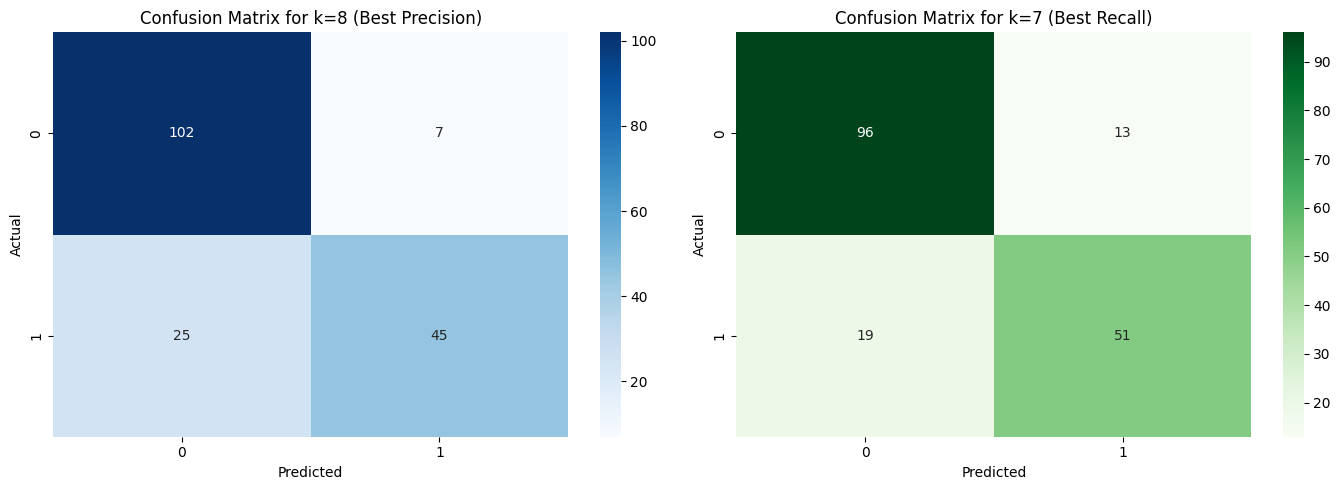

In [88]:
# Confusion matrices
Y_test_pred_precision = knn_best_precision.predict(X_test_scaled)
Y_test_pred_recall = knn_best_recall.predict(X_test_scaled)

cm_precision = confusion_matrix(Y_test, Y_test_pred_precision)
cm_recall = confusion_matrix(Y_test, Y_test_pred_recall)

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm_precision, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix for k={best_precision_k} (Best Precision)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(cm_recall, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title(f'Confusion Matrix for k={best_recall_k} (Best Recall)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

---
# 7. IoT and Sensor Data

**Exercise i:** MQTT with Diabetes Dataset (from slide 16, bullet 2)
**Exercise ii:** PCA Analysis (from pdm_task)

Tasks for PCA:
1. Apply PCA with up to 5 components
2. Visualize variance explained by each component
3. Visualize first 2 principal components colored by timestep
4. Simulate a new position
5. Plot new point in original 2D PCA graph

## PCA Analysis on Simulated Sensor Data

In [89]:
# Step 1: Simulate synthetic predictive maintenance dataset
np.random.seed(42)
time_steps = 10000

sensors = {}
for i in range(1, 21):
    sensors[f'Sensor{i}'] = np.linspace(50, 100, time_steps) + np.random.normal(0, 20, time_steps)

# Combine into a DataFrame
sensor_data = pd.DataFrame(sensors)
print("Sample Data:")
print(sensor_data.head())

Sample Data:
     Sensor1    Sensor2    Sensor3    Sensor4    Sensor5    Sensor6  \
0  59.934283  36.430105  56.965725  10.388561  40.562849  51.964123   
1  47.239714  43.895011  55.671472  28.905288  70.259050  48.722836   
2  62.963772  38.062380  31.279604  38.269433  46.046264  69.045816   
3  80.475599  52.223362  61.606686  53.008380  51.826387  80.671624   
4  45.336935  73.963573  20.218348  70.503249  64.367814  63.756941   

     Sensor7    Sensor8    Sensor9   Sensor10   Sensor11   Sensor12  \
0  51.576755  56.403048  63.280022  69.217891  70.611892  66.017477   
1  61.262950  72.314233  44.082680  42.605706  26.897905  49.021813   
2  56.832040  19.905237  48.678273  38.418383  61.518745  41.079748   
3  24.456718  84.807115  46.507354  68.681245  37.630232  53.375301   
4  46.295596  56.621738  60.301076  -4.610793  43.471946   7.484493   

    Sensor13   Sensor14   Sensor15   Sensor16   Sensor17   Sensor18  \
0  45.626995  72.350652  44.689254  77.397560  78.652455  13.5

In [90]:
# Step 2: Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(sensor_data)

print("Scaled Data Sample:")
print(pd.DataFrame(scaled_data, columns=sensor_data.columns).head())

Scaled Data Sample:
    Sensor1   Sensor2   Sensor3   Sensor4   Sensor5   Sensor6   Sensor7  \
0 -0.610580 -1.566006 -0.725010 -2.596654 -1.407431 -0.927666 -0.969437   
1 -1.126525 -1.265030 -0.777771 -1.850742 -0.198347 -1.057996 -0.572396   
2 -0.487452 -1.500195 -1.772111 -1.473524 -1.184173 -0.240819 -0.754021   
3  0.224281 -0.929241 -0.535820 -0.879792 -0.948835  0.226649 -2.081098   
4 -1.203859 -0.052701 -2.223025 -0.175043 -0.438209 -0.453482 -1.185914   

    Sensor8   Sensor9  Sensor10  Sensor11  Sensor12  Sensor13  Sensor14  \
0 -0.746813 -0.479506 -0.232249 -0.186682 -0.367113 -1.184181 -0.110562   
1 -0.106939 -1.258090 -1.320570 -1.955170 -1.054209 -0.697301 -0.772550   
2 -2.214587 -1.071707 -1.491814 -0.554553 -1.375289 -0.412171 -0.701019   
3  0.395468 -1.159753 -0.254195 -1.520984 -0.878208 -1.964016 -1.982653   
4 -0.738018 -0.600323 -3.251518 -1.284652 -2.733470 -0.924990 -0.686938   

   Sensor15  Sensor16  Sensor17  Sensor18  Sensor19  Sensor20  
0 -1.220616  0

## Task 1: Apply PCA with 5 Components

In [91]:
# Apply PCA with up to 5 components
pca_5 = PCA(n_components=5)
pca_5_result = pca_5.fit_transform(scaled_data)

# Print explained variance ratio for each component
print("Explained variance ratio for each component:")
for i, ratio in enumerate(pca_5.explained_variance_ratio_):
    print(f"Component {i+1}: {ratio:.4f}")

Explained variance ratio for each component:
Component 1: 0.3769
Component 2: 0.0359
Component 3: 0.0351
Component 4: 0.0349
Component 5: 0.0343


## Task 2: Visualize Variance Explained

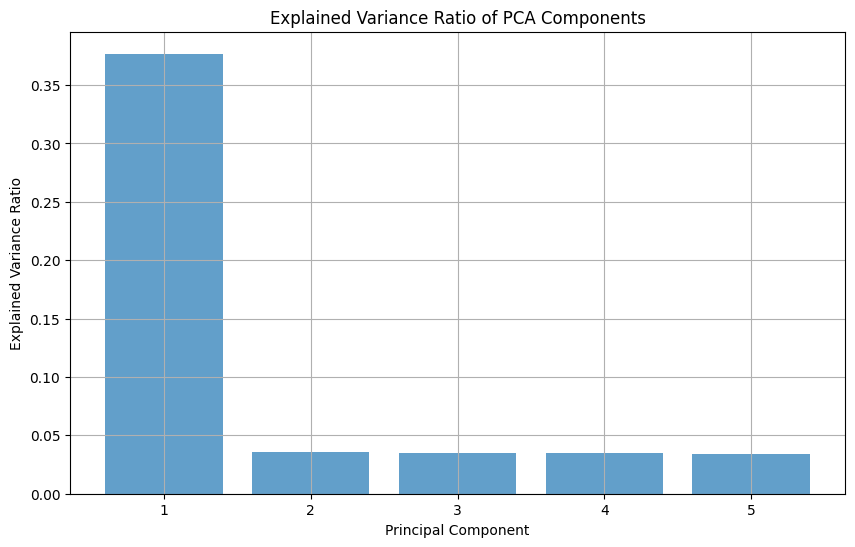

In [92]:
# Visualize how much variance is defined by each component
plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), pca_5.explained_variance_ratio_, alpha=0.7)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance Ratio of PCA Components")
plt.grid()
plt.show()

## Task 3: Visualize 2D PCA

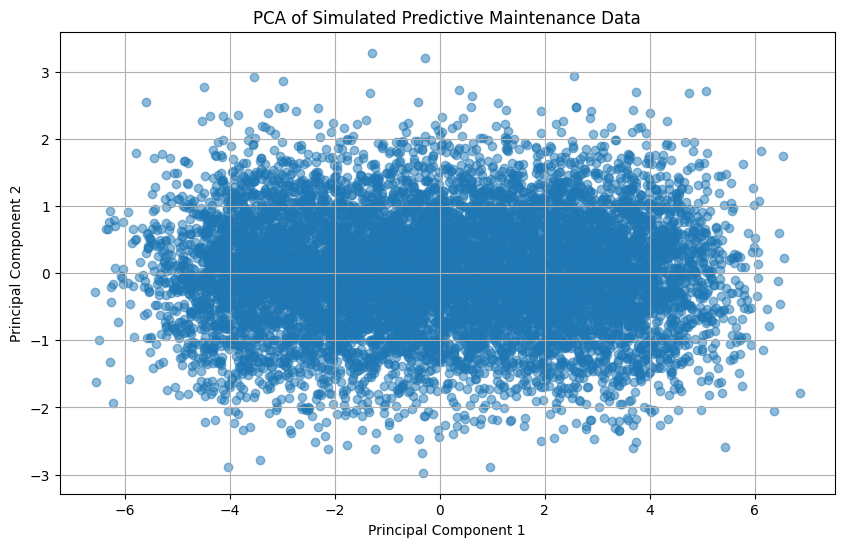

In [93]:
# Apply PCA with 2 components for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

# Plot the PCA results
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5)
plt.title("PCA of Simulated Predictive Maintenance Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid()
plt.show()

## Task 4 & 5: Simulate New Point and Plot

In [94]:
# Create a new point with 20 sensor values
new_point = {}
for i in range(1, 21):
    new_point[f'Sensor{i}'] = np.random.uniform(50, 100) + np.random.normal(0, 20)

new_point_df = pd.DataFrame([new_point])
print("New simulated point:")
print(new_point_df)

# Scale and transform
new_point_scaled = scaler.transform(new_point_df)
new_point_transformed = pca.transform(new_point_scaled)
print("\nPCA-transformed new simulated point:")
print(new_point_transformed)

New simulated point:
    Sensor1    Sensor2    Sensor3    Sensor4     Sensor5     Sensor6  \
0  71.11035  77.718551  46.423748  84.290088  113.050647  102.042586   

     Sensor7    Sensor8    Sensor9   Sensor10   Sensor11   Sensor12  \
0  76.312061  83.300693  47.912127  75.908431  56.108257  84.615147   

    Sensor13    Sensor14   Sensor15   Sensor16  Sensor17  Sensor18   Sensor19  \
0  75.992426  107.482718  71.607757  97.585286  91.28264  77.46756  87.564371   

     Sensor20  
0  110.972088  

PCA-transformed new simulated point:
[[ 1.24199703 -0.76560423]]


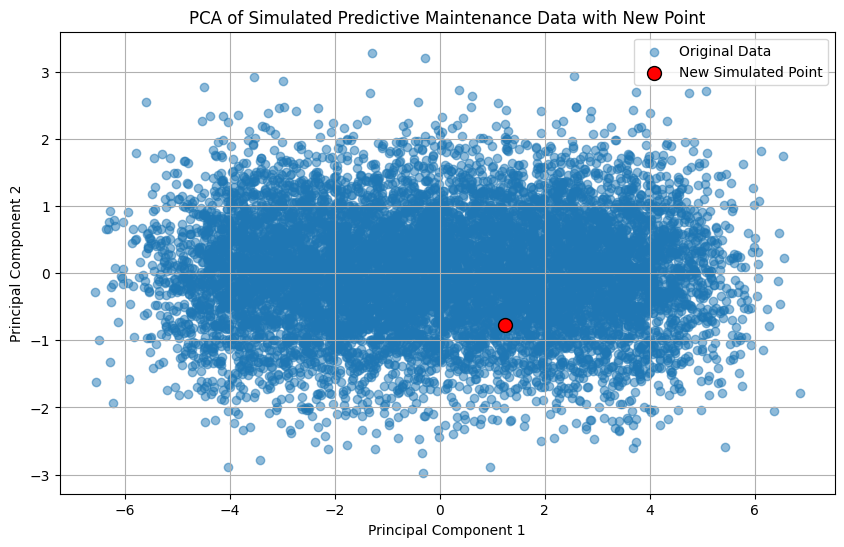

In [95]:
# Plot new point on PCA graph
plt.figure(figsize=(10, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.5, label="Original Data")
plt.scatter(new_point_transformed[0, 0], new_point_transformed[0, 1], 
           color='red', label="New Simulated Point", edgecolor='black', s=100)
plt.title("PCA of Simulated Predictive Maintenance Data with New Point")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid()
plt.show()

## MQTT Exercise with Diabetes Dataset

In [96]:
import paho.mqtt.client as mqtt

# Load and prepare diabetes data
diabetes = pd.read_csv("Data/diabetes.csv")
diabetes_isolated = diabetes[["Glucose", "BloodPressure", "Insulin", "Outcome"]]

# Scale features to [0, 1]
scaler = MinMaxScaler()
diabetes_scaled = pd.DataFrame(scaler.fit_transform(diabetes_isolated.drop("Outcome", axis=1)), 
                               columns=diabetes_isolated.columns[:-1])
diabetes_scaled["Outcome"] = diabetes_isolated["Outcome"]

print("Scaled diabetes data:")
print(diabetes_scaled.head())

Scaled diabetes data:
    Glucose  BloodPressure   Insulin  Outcome
0  0.743719       0.590164  0.000000        1
1  0.427136       0.540984  0.000000        0
2  0.919598       0.524590  0.000000        1
3  0.447236       0.540984  0.111111        0
4  0.688442       0.327869  0.198582        1


In [97]:
# MQTT setup
def on_connect(client, userdata, flags, rc):
    if rc == 0:
        print("Connected to MQTT Broker!")
    else:
        print("Failed to connect, return code %d\n", rc)

# Setup MQTT client
mqtt_client = mqtt.Client()
# Note: Actual MQTT implementation would require active broker connection

/tmp/ipykernel_12472/3116460210.py:9: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  mqtt_client = mqtt.Client()


---
# 8. Clustering

**Exercise 1:** Bike Station Clustering

Tasks:
1. Apply K-Means clustering with different K values using Elbow method
2. Visualize K-Means clustering for best K
3. Apply Agglomerative clustering with dendrogram
4. Visualize Agglomerative clustering
5. Apply DBSCAN with different eps and min_samples
6. Visualize DBSCAN clustering
7. Calculate Silhouette scores and Adjusted Rand Index for comparison

In [98]:
# Load bike station data
bikes = pd.read_csv("Data/Ch5_bike_station_locations.csv")
print(bikes.info())
print(bikes.describe())
bikes.head()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   244 non-null    float64
 1   longitude  244 non-null    float64
dtypes: float64(2)
memory usage: 3.9 KB
None
         latitude   longitude
count  244.000000  244.000000
mean    38.914289  -77.010109
std      0.035435    0.041084
min     38.827425  -77.106502
25%     38.891574  -77.031987
50%     38.916397  -77.011474
75%     38.935887  -76.985866
max     38.987980  -76.919470


,latitude,longitude
0,38.956590,-76.993437
1,38.905218,-77.001496
2,38.980858,-77.054722
3,38.902925,-76.929915
4,38.949498,-77.093620


## Data Preparation

In [99]:
# Scale the data before clustering
X = bikes[["latitude", "longitude"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## K-Means Clustering

In [100]:
# Fit K-means with K=3
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

print("Cluster labels:", kmeans.labels_)
print("Number of points in each cluster:", np.bincount(kmeans.labels_))

Cluster labels: [1 0 2 0 2 2 0 0 0 0 2 0 0 0 1 2 2 1 2 0 0 1 1 0 2 1 2 1 1 0 0 0 1 2 1 2 1
 0 1 1 0 1 2 1 0 1 0 2 0 2 0 1 0 0 0 0 0 0 1 0 2 2 2 1 0 0 0 1 1 1 1 1 1 1
 0 1 1 1 0 2 0 2 2 2 1 2 0 1 0 0 1 0 2 0 0 1 2 0 1 2 1 0 2 2 1 1 2 1 1 1 1
 1 0 1 2 0 1 1 0 1 0 1 2 2 2 0 0 0 0 0 1 1 2 2 1 0 0 0 2 1 1 1 1 2 1 2 2 1
 1 0 2 1 0 1 1 0 2 0 1 1 0 0 0 0 1 0 2 2 1 0 1 1 1 0 2 1 0 1 1 2 0 0 0 2 0
 0 0 2 0 1 0 0 2 1 0 0 0 1 1 1 2 1 2 2 1 0 0 2 1 1 1 0 0 1 1 0 2 1 0 1 1 2
 1 0 1 0 0 1 0 0 1 1 1 2 0 0 0 2 0 2 0 1 0 1]
Number of points in each cluster: [95 93 56]


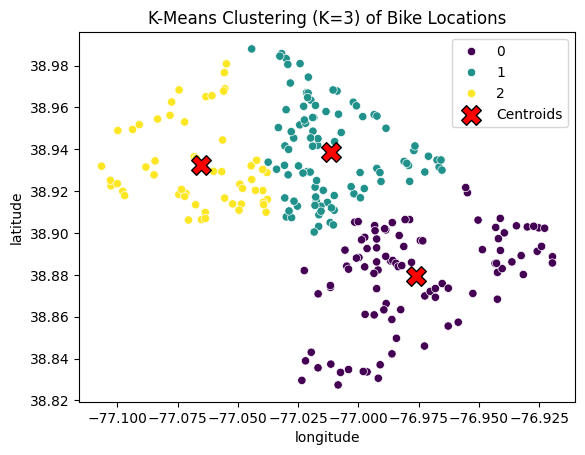

In [101]:
# Visualize the clustering
bikes["3MeansCluster"] = kmeans.labels_

# Transform cluster centers back to original scale
cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

sns.scatterplot(data=bikes, x="longitude", y="latitude", hue="3MeansCluster", palette="viridis")
plt.scatter(x=cluster_centers_original[:,1], y=cluster_centers_original[:,0], 
           color='red', s=200, marker='X', edgecolor='black', label='Centroids')
plt.title("K-Means Clustering (K=3) of Bike Locations")
plt.legend()
plt.show()

---
# 9. Machine Learning Operations (MLOps)

**Exercise i:** Complete tasks in mlflow_task.ipynb
**Exercise ii:** Complete tasks 1-6 in MLOps exercises.ipynb

*Note: These exercises require separate notebooks not included in exercises.ipynb*

---
# 10. Social Network Analysis and Large Datasets

**Exercise i:** Write code to turn edge list into adjacency matrix
**Exercise ii:** Calculate degree centrality and betweenness centrality
**Exercise iii:** Compare Pandas and Polars

*Note: These exercises require separate notebooks (01_network_exercise.ipynb, 02_climate_obstruction.ipynb, 03_polars_exercise.ipynb)*

In [102]:
import networkx as nx

---
# 11. Explainability

**Exercise:** From slide 25 of Explainability.pptx

Tasks:
1. Train at least two models on energy dataset (may use last 5 years)
2. Use SHAP: at least 3 local plots per model + 1 global plot
3. Use LIME: explain 3 rows/predictions
4. Compare SHAP and LIME results

In [103]:
# Using bike sharing dataset from earlier
X = hour.drop(columns=["cnt", "dteday", "datetime_obj"])
Y = hour["cnt"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

## Model 1: Linear Regression

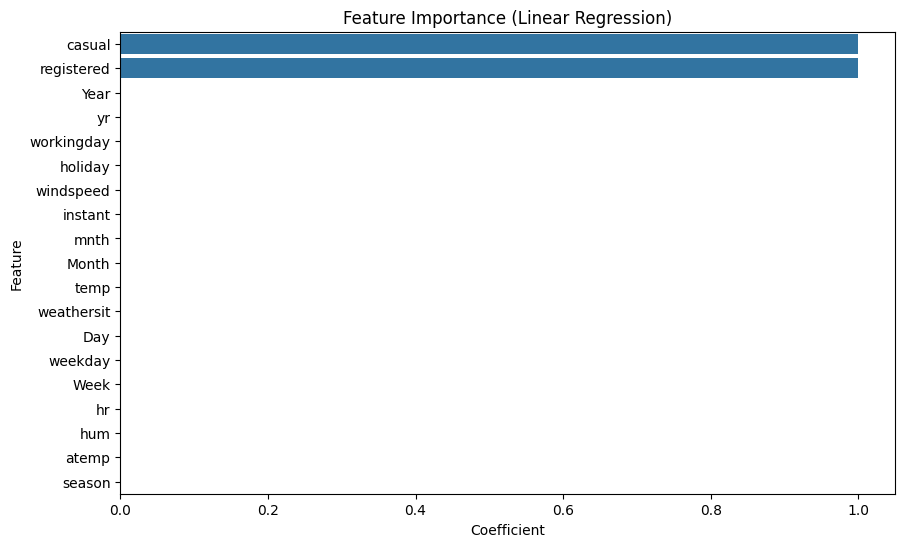

In [104]:
# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, Y_train)

# Feature importance via correlation
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': lin_reg.coef_})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance)
plt.title('Feature Importance (Linear Regression)')
plt.show()

## Model 2: Random Forest

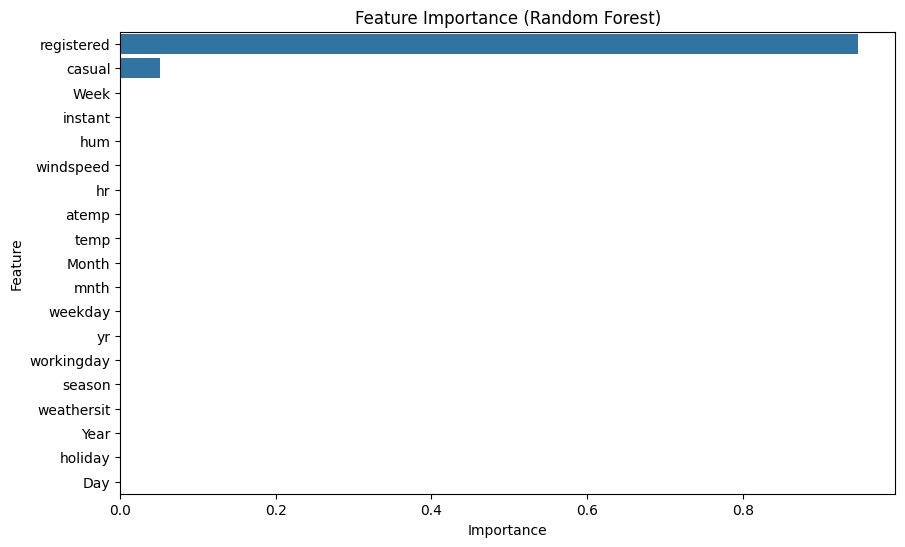

In [105]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

# Feature importance
importances = rf.feature_importances_
feature_importance_rf = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_rf)
plt.title('Feature Importance (Random Forest)')
plt.show()

## Partial Dependence Plot

Partial Dependence Plot (PDP) shows how the model's prediction changes as a feature varies.


/home/xilas/DaT/python3venv/lib/python3.12/site-packages/sklearn/inspection/_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


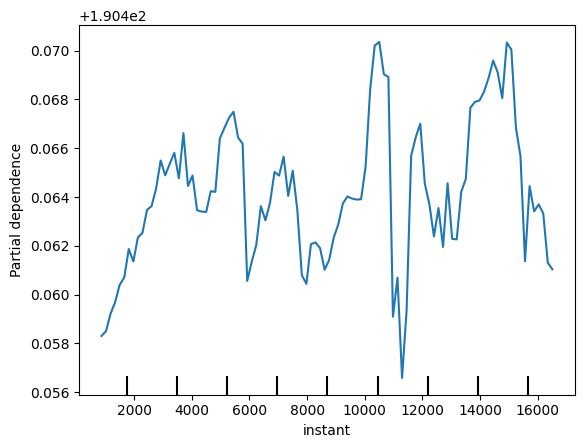

In [106]:
# Partial Dependence Plot
print("Partial Dependence Plot (PDP) shows how the model's prediction changes as a feature varies.")
feature_idx = 0  # Change to visualize different features
PartialDependenceDisplay.from_estimator(rf, X_train, [feature_idx])
plt.show()

---
# 12. Neural Networks and Deep Learning

**Exercise 2:** From "Exercises in neural network and deep learning II.ipynb"

*Note: This exercise requires accessing the specific notebook and dataset*

---
# 13. Generative AI

**Exercise:** Tasks from rag_task.ipynb

Tasks:
1. Create RAG pipeline
2. Try at least 3 types of chunking (paragraphs, sentences, punctuation)
3. Test different question formulations
4. Try at least one other similarity/distance function

*Note: This exercise requires accessing rag_task.ipynb*

---
# 14. Ethical Reflections on Data Science

**Exercise 1:** From "Exercises in Fairness in Machine Learning.ipynb"

*Note: This exercise requires accessing the specific notebook*